# Mark 1

Use `numdifftools` to find the gradient of the function $f(x,y) = (2-x)^2 + 50(y-x^2)^2$ at points 
a. $(x,y) = (1,1)$
b. $(x,y) = (2,4)$

Plot the function and determine whether either of the points is a minimum. 

Gradient at (1,1): [-2.  0.]
Gradient at (2,4): [2.57727762e-13 4.41409886e-14]

Start from: [1 1]
gamma = 0.01
flag = 0
x = [-6.80049468e+18  2.26108235e+12]
iterations = 81
gradient = [0. 0.]

Start from: [2 4]
gamma = 0.001
flag = 0
x = [2. 4.]
iterations = 1
gradient = [-2.01952836e-13  1.33501650e-13]


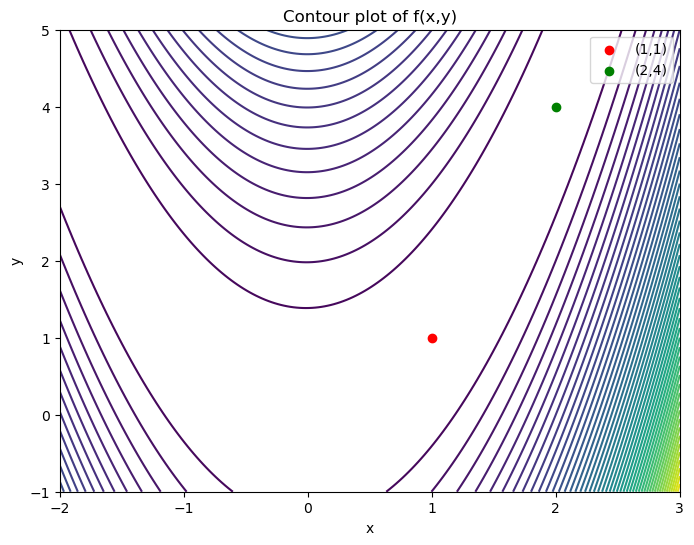

In [2]:
%matplotlib inline
from numpy.random import normal, randint
from numpy import zeros, array
from numpy.linalg import norm
import numdifftools as nd
import numpy as np
import matplotlib.pyplot as plt

def fun(x):
    return (2-x[0])**2+50*(x[1]-x[0]**2)**2
grad = nd.Gradient(fun)
f1 = np.array([1,1])
f2 = np.array([2,4])
gf1 = grad(f1)
gf2 = grad(f2)
print("Gradient at (1,1):", gf1)
print("Gradient at (2,4):", gf2)
def degradient(startpoint,gamma):
    x = startpoint.copy()
    counter = 0
    max_iter = 500
    toler = 1e-4
    while True:
        counter +=1
        x = x - gamma * grad(x)
        if np.linalg.norm(grad(x)) < toler:
            flag = 0
            break
        elif counter >= max_iter:
            flag = 1
            break
    print("\nStart from:", startpoint)
    print("gamma =", gamma)
    print("flag =", flag)
    print("x =", x)
    print("iterations =", counter)
    print("gradient =", grad(x))
degradient(f1,0.01)
degradient(f2,0.001)

x = np.linspace(-2, 3, 200)
y = np.linspace(-1, 5, 200)
X, Y = np.meshgrid(x, y)

Z = (2 - X)**2 + 50 * (Y - X**2)**2
plt.figure(figsize=(8,6))
plt.contour(X, Y, Z, levels=50)

plt.scatter(1,1, color='red', label='(1,1)')
plt.scatter(2,4, color='green', label='(2,4)')

plt.legend()
plt.title("Contour plot of f(x,y)")
plt.xlabel("x")
plt.ylabel("y")

plt.show()


### Analysis

The gradient at (1,1) is non-zero, so it is not a minimum. Gradient descent starting from this point does not converge properly.

The gradient at (2,4) is approximately zero, and the algorithm converges immediately. This confirms that (2,4) is a minimum.

The contour plot shows level curves of the function. Although the lines near (1,1) are relatively sparse, the gradient is not zero, so the point is not a minimum.

The function is a sum of squared terms and therefore always non-negative. It reaches its lowest value at (2,4), making it the global minimum.

# Mark 2


Apply the gradient descent algorithm to the function $f(x,y) = (2-x)^2 + 50(y-x^2)^2$. Use $(x,y)  = (1,1)$ as the starting point. 

In [ ]:
mark2 = np.array([1,1])
degradient(mark2, 0.001)


Start from: [1 1]
gamma = 0.001
flag = 1
x = [1.16249857 1.34531876]
iterations = 500
gradient = [-0.260437   -0.60841618]


The same gradient descent function defined above can be reused here, since the algorithm is identical. In this task, it is applied with the starting point (1,1).

# Mark 3

Rewrite the gradient descent algorithm as a proper function and test it for function minimization and data fitting problems. 

One function minimization problem could be the first problem of the set with the coeffcient $50$ replaced with a smaller number (like $10$). Data fitting could be for example to fit a function with more than one independent variable. 

In [ ]:
import numpy as np
import numdifftools as nd
from numpy.random import normal

def degradient(fun, start_point, gamma=0.001, toler=1e-4, max_iter=500):
    grad = nd.Gradient(fun)
    x = np.array(start_point, dtype=float).copy()
    counter = 0

    while True:
        counter += 1
        x = x - gamma * grad(x)

        if np.linalg.norm(grad(x)) < toler:
            flag = 0
            break
        elif counter >= max_iter:
            flag = 1
            break

    return x, counter, grad(x), flag


In [ ]:
def fun_min(x):
    return (2 - x[0])**2 + 10 * (x[1] - x[0]**2)**2

start1 = np.array([1, 1])
x_min, iter_min, grad_min, flag_min = degradient(fun_min, start1)

print("Function minimization")
print("Start from:", start1)
print("x =", x_min)
print("iterations =", iter_min)
print("gradient =", grad_min)
print("flag =", flag_min)

Function minimization
Start from: [1 1]
x = [1.16858519 1.33541566]
iterations = 500
gradient = [-0.25231549 -0.60351361]
flag = 1


In [ ]:
np.random.seed(0)

n = 50
x1 = normal(loc=2.0, scale=0.5, size=n)
x2 = normal(loc=1.0, scale=0.3, size=n)
#just choose a simple formula to simulate  
ydata = 2*x1 + 2*x2 + 2 + normal(loc=0, scale=0.2, size=n)

def loss(par):
    y_pred = par[0]*x1 + par[1]*x2 + par[2]
    return 0.5 * np.linalg.norm(ydata - y_pred)**2

start2 = np.array([0.0, 0.0, 0.0])
par_opt, iter_fit, grad_fit, flag_fit = degradient(loss, start2, gamma=0.001, max_iter=2000)

print("\nData fitting")
print("Start from:", start2)
print("optimal parameters =", par_opt)
print("iterations =", iter_fit)
print("gradient =", grad_fit)
print("flag =", flag_fit)


Data fitting
Start from: [0. 0. 0.]
optimal parameters = [2.02780081 1.90226461 2.08986995]
iterations = 2000
gradient = [ 0.00945328  0.02954688 -0.05014406]
flag = 1


 ### Data Fitting notes
I was also trying to generate data by ydata = 3*x1 + 2*x2 + 1 + normal(loc=0, scale=0.2, size=n), and got optimal parameters = [3.013, 1.857, 1.166]. 

But I modified them as the same 2.
This proves that the estimated parameters are close to the true values used to generate the data.  
When the coefficients in the data generation model are changed, the fitted parameters also change accordingly.

This shows that gradient descent does not recover fixed values, but learns the parameters from the data.  
The small differences between the estimated and true values are due to the added noise.